In [1]:
from google.colab import files
uploaded = files.upload()

Saving AEP_hourly.csv to AEP_hourly.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# Load energy data
df = pd.read_csv('AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()
df = df[~df.index.duplicated(keep='first')]

# Resample to daily
df_daily = df.resample('D').mean()
df_daily = df_daily['2016-01-01':'2018-08-03']

print("Energy data shape:", df_daily.shape)
print(df_daily.head())

Energy data shape: (946, 1)
                  AEP_MW
Datetime                
2016-01-01  14085.583333
2016-01-02  14484.083333
2016-01-03  14621.583333
2016-01-04  16866.333333
2016-01-05  17948.458333


In [3]:
# Fetch historical weather data from Open-Meteo (free, no API key needed)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 39.9612,
    "longitude": -82.9988,
    "start_date": "2016-01-01",
    "end_date": "2018-08-03",
    "daily": "temperature_2m_mean",
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
weather = response.json()

# Convert to dataframe
weather_df = pd.DataFrame({
    'Datetime': pd.to_datetime(weather['daily']['time']),
    'temperature': weather['daily']['temperature_2m_mean']
})
weather_df = weather_df.set_index('Datetime')

print("Weather data shape:", weather_df.shape)
print(weather_df.head())

Weather data shape: (946, 1)
            temperature
Datetime               
2016-01-01         -0.9
2016-01-02         -0.9
2016-01-03         -0.3
2016-01-04         -2.7
2016-01-05         -5.3


Combined shape: (946, 2)
                  AEP_MW  temperature
Datetime                             
2016-01-01  14085.583333         -0.9
2016-01-02  14484.083333         -0.9
2016-01-03  14621.583333         -0.3
2016-01-04  16866.333333         -2.7
2016-01-05  17948.458333         -5.3


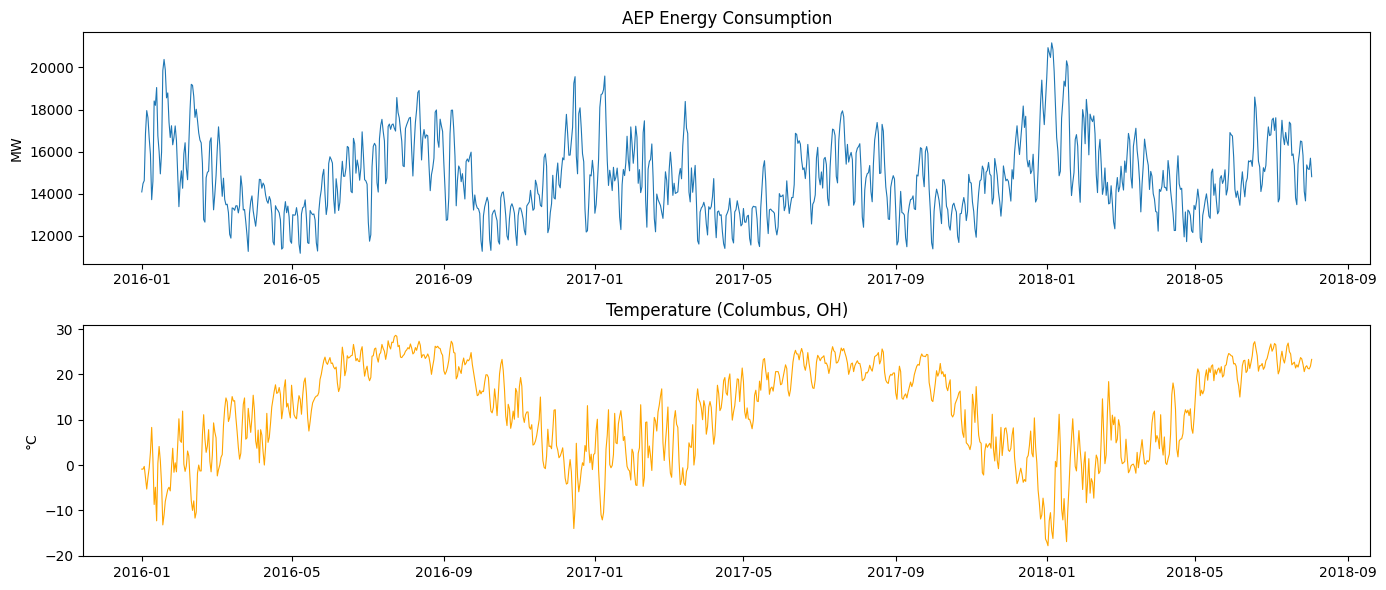


Correlation between load and temperature: -0.246


In [4]:
# Merge energy and weather data
df_combined = pd.concat([df_daily, weather_df], axis=1)
df_combined.columns = ['AEP_MW', 'temperature']
df_combined = df_combined.dropna()

print("Combined shape:", df_combined.shape)
print(df_combined.head())

# Plot both series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
ax1.plot(df_combined['AEP_MW'], linewidth=0.8)
ax1.set_title('AEP Energy Consumption')
ax1.set_ylabel('MW')

ax2.plot(df_combined['temperature'], linewidth=0.8, color='orange')
ax2.set_title('Temperature (Columbus, OH)')
ax2.set_ylabel('°C')

plt.tight_layout()
plt.show()

# Check correlation
corr = df_combined['AEP_MW'].corr(df_combined['temperature'])
print(f"\nCorrelation between load and temperature: {corr:.3f}")

In [5]:
# Train/test split — last 90 days as test
train = df_combined.iloc[:-90]
test = df_combined.iloc[-90:]

print("Train size:", len(train))
print("Test size:", len(test))

# Normalize each feature separately
mean_load = train['AEP_MW'].mean()
std_load = train['AEP_MW'].std()
mean_temp = train['temperature'].mean()
std_temp = train['temperature'].std()

train_norm = train.copy()
test_norm = test.copy()

train_norm['AEP_MW'] = (train['AEP_MW'] - mean_load) / std_load
train_norm['temperature'] = (train['temperature'] - mean_temp) / std_temp
test_norm['AEP_MW'] = (test['AEP_MW'] - mean_load) / std_load
test_norm['temperature'] = (test['temperature'] - mean_temp) / std_temp

print("\nNormalized train sample:")
print(train_norm.head())

Train size: 856
Test size: 90

Normalized train sample:
              AEP_MW  temperature
Datetime                         
2016-01-01 -0.348056    -1.175732
2016-01-02 -0.135322    -1.175732
2016-01-03 -0.061920    -1.116791
2016-01-04  1.136407    -1.352557
2016-01-05  1.714084    -1.607970


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEQ_LEN = 30

def create_sequences_univariate(data, seq_len=30):
    X, y = [], []
    values = data['AEP_MW'].values
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len].reshape(-1, 1))
        y.append(values[i+seq_len])
    return np.array(X), np.array(y)

def create_sequences_multivariate(data, seq_len=30):
    X, y = [], []
    values = data[['AEP_MW', 'temperature']].values
    load = data['AEP_MW'].values
    for i in range(len(values) - seq_len):
        X.append(values[i:i+seq_len])
        y.append(load[i+seq_len])
    return np.array(X), np.array(y)

# Univariate sequences
X_train_uni, y_train_uni = create_sequences_univariate(train_norm, SEQ_LEN)
X_test_uni, y_test_uni = create_sequences_univariate(test_norm, SEQ_LEN)

# Multivariate sequences
X_train_multi, y_train_multi = create_sequences_multivariate(train_norm, SEQ_LEN)
X_test_multi, y_test_multi = create_sequences_multivariate(test_norm, SEQ_LEN)

print("Univariate X_train shape:", X_train_uni.shape)
print("Multivariate X_train shape:", X_train_multi.shape)

Univariate X_train shape: (826, 30, 1)
Multivariate X_train shape: (826, 30, 2)


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

def train_model(X_train, y_train, input_size, epochs=50):
    X_t = torch.FloatTensor(X_train)
    y_t = torch.FloatTensor(y_train)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = LSTMModel(input_size=input_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
    return model

print("Training univariate LSTM...")
model_uni = train_model(X_train_uni, y_train_uni, input_size=1)

print("\nTraining multivariate LSTM...")
model_multi = train_model(X_train_multi, y_train_multi, input_size=2)

Using device: cpu
Training univariate LSTM...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([26])) that is different to the input size (torch.Size([26, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 10/50 - Loss: 24.7505
Epoch 20/50 - Loss: 24.7602
Epoch 30/50 - Loss: 24.7919
Epoch 40/50 - Loss: 24.8517
Epoch 50/50 - Loss: 24.8865

Training multivariate LSTM...
Epoch 10/50 - Loss: 24.8713
Epoch 20/50 - Loss: 24.8521
Epoch 30/50 - Loss: 24.8215
Epoch 40/50 - Loss: 24.8210
Epoch 50/50 - Loss: 24.8184


In [8]:
def train_model(X_train, y_train, input_size, epochs=50):
    X_t = torch.FloatTensor(X_train)
    y_t = torch.FloatTensor(y_train).reshape(-1, 1)  # Fix: reshape target
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = LSTMModel(input_size=input_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
    return model

print("Training univariate LSTM...")
model_uni = train_model(X_train_uni, y_train_uni, input_size=1)

print("\nTraining multivariate LSTM...")
model_multi = train_model(X_train_multi, y_train_multi, input_size=2)

Training univariate LSTM...
Epoch 10/50 - Loss: 6.2540
Epoch 20/50 - Loss: 6.0606
Epoch 30/50 - Loss: 4.9237
Epoch 40/50 - Loss: 4.0349
Epoch 50/50 - Loss: 4.1513

Training multivariate LSTM...
Epoch 10/50 - Loss: 6.4159
Epoch 20/50 - Loss: 5.5531
Epoch 30/50 - Loss: 4.9951
Epoch 40/50 - Loss: 3.8863
Epoch 50/50 - Loss: 3.0484


Univariate LSTM   MAPE: 3.48%  |  RMSE: 676.30 MW
Multivariate LSTM MAPE: 3.32%  |  RMSE: 623.16 MW

Improvement from adding temperature: 4.6%


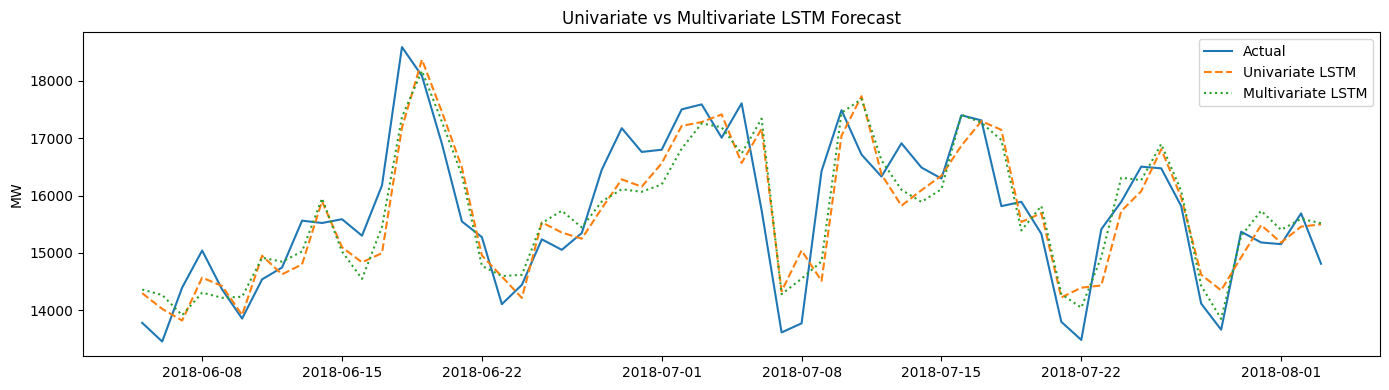

In [9]:
def evaluate_model(model, X_test, y_test, mean, std):
    model.eval()
    X_t = torch.FloatTensor(X_test)
    with torch.no_grad():
        pred_norm = model(X_t.to(device)).cpu().numpy()
    pred = (pred_norm * std) + mean
    actual = (y_test * std) + mean
    mape = np.mean(np.abs((actual - pred.flatten()) / actual)) * 100
    rmse = np.sqrt(np.mean((actual - pred.flatten()) ** 2))
    return pred.flatten(), actual, mape, rmse

# Evaluate both models
pred_uni, actual, mape_uni, rmse_uni = evaluate_model(
    model_uni, X_test_uni, y_test_uni, mean_load, std_load)

pred_multi, actual, mape_multi, rmse_multi = evaluate_model(
    model_multi, X_test_multi, y_test_multi, mean_load, std_load)

print(f"Univariate LSTM   MAPE: {mape_uni:.2f}%  |  RMSE: {rmse_uni:.2f} MW")
print(f"Multivariate LSTM MAPE: {mape_multi:.2f}%  |  RMSE: {rmse_multi:.2f} MW")
print(f"\nImprovement from adding temperature: {((mape_uni - mape_multi)/mape_uni)*100:.1f}%")

# Plot
plt.figure(figsize=(14,4))
test_index = test.index[SEQ_LEN:]
plt.plot(test_index, actual, label='Actual')
plt.plot(test_index, pred_uni, label='Univariate LSTM', linestyle='--')
plt.plot(test_index, pred_multi, label='Multivariate LSTM', linestyle=':')
plt.title('Univariate vs Multivariate LSTM Forecast')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print("--- Project 2 Summary ---")
print(f"Univariate LSTM MAPE:   {mape_uni:.2f}%")
print(f"Multivariate LSTM MAPE: {mape_multi:.2f}%")
print(f"Improvement:            {((mape_uni - mape_multi)/mape_uni)*100:.1f}%")
print(f"\nCorrelation (load vs temperature): -0.246")
print("Adding temperature as a covariate provides modest but consistent improvement,")
print("reflecting the non-linear seasonal relationship between weather and energy demand.")

--- Project 2 Summary ---
Univariate LSTM MAPE:   3.48%
Multivariate LSTM MAPE: 3.32%
Improvement:            4.6%

Correlation (load vs temperature): -0.246
Adding temperature as a covariate provides modest but consistent improvement,
reflecting the non-linear seasonal relationship between weather and energy demand.
